# Clustering với DBSCAN

Nguồn: https://www.digitalvidya.com/blog/the-top-5-clustering-algorithms-data-scientists-should-know/
![image.png](https://imgur.com/9D6aAF2.gif)

In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định
(Cùng dữ liệu giả với `03_Demo-kMeans.ipynb`)

In [2]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

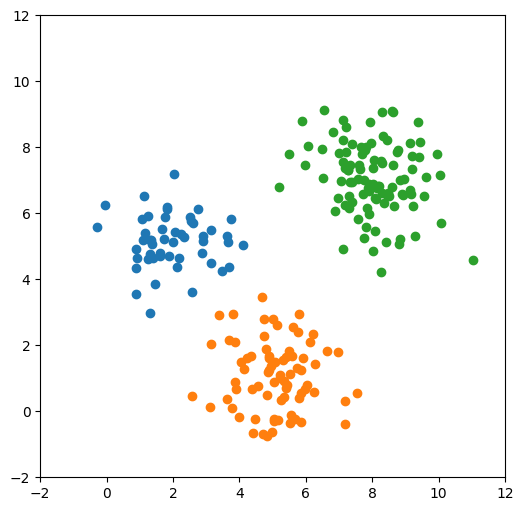

In [3]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập

In [4]:
dat1 = np.stack([x1,y1]).T
dat1.shape

(50, 2)

In [5]:
dat2 = np.stack([x2,y2]).T
dat3 = np.stack([x3,y3]).T

In [6]:
dat = np.vstack([dat1, dat2, dat3])
dat.shape

(225, 2)

### Sắp ngẫu nhiên các dòng

In [7]:
np.random.seed(2)
np.random.shuffle(dat)

### Kiểm tra lại với biểu đồ scatter

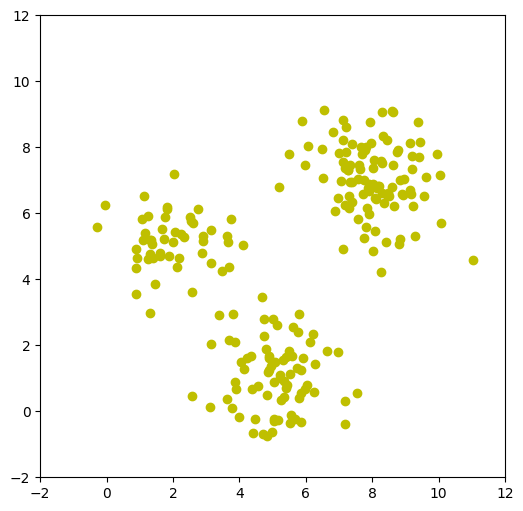

In [8]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.show()

## 2. Thực hiện phân cụm bằng DBSCAN

**=== Import lớp DBSCAN từ thư viện sklearn ===**

In [9]:
from sklearn.cluster import DBSCAN

### 2.1. Khởi tạo model và fit vào dữ liệu

In [10]:
# Giả sử chọn epsilon = 1, minPoints = 5
dbscan = DBSCAN(eps=1, min_samples=5)

**=== Thực hiện fit vào dữ liệu ===**

In [11]:
dbscan.fit(dat)

DBSCAN(eps=1)

### 2.2. Kiểm tra kết quả các cluster tìm được

**=== Lấy ra nhãn các clusters ===**

In [12]:
cluster = dbscan.labels_

In [ ]:
cluster

array([ 0,  0,  2,  1,  1,  2,  0,  1,  1,  1,  1,  0,  0,  2,  2,  0,  2,
        0,  1,  2,  1,  0,  0,  2,  0,  0,  1,  1,  1,  0,  0,  2,  2,  1,
        1,  1,  0,  2,  2,  2,  2,  2,  0, -1,  0, -1,  1,  2,  0,  2,  0,
        1,  2,  0,  1,  0,  0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  2,  1,
        2,  0,  0,  0, -1,  2,  2,  0,  0,  1,  0,  0,  0,  0,  0,  0,  1,
        0,  0, -1, -1,  0,  0,  2,  0,  0,  0,  0,  1,  1,  1,  0,  0,  2,
        0,  0,  0,  1,  1, -1,  0, -1,  1,  0,  1,  0,  0,  0,  1,  1,  2,
        1,  0,  0,  0,  0,  0,  0,  0,  2,  1,  1,  2,  2,  1,  0,  0,  0,
        2,  1,  0,  0,  1,  1,  2,  0,  0,  1,  0,  1,  0,  1,  1,  1,  0,
        1,  2,  1,  1,  0,  1,  2,  2,  0,  1,  0,  2,  2,  0,  1,  1,  1,
        1,  1,  1,  0,  0,  0,  0,  0,  0,  2,  2,  0,  0,  1,  1,  1,  0,
        1,  0,  2,  1,  1,  1,  0,  1,  2,  2,  1,  1,  1,  0,  2,  1,  0,
        0,  2,  1,  1,  0,  2,  1,  2,  0,  1,  0,  0,  2,  1,  1,  0,  2,
        2,  1,  2,  0], d

**=== Đếm xem mỗi cluster có bao nhiêu điểm ===**

In [13]:
np.unique(cluster, return_counts=True)

(array([-1,  0,  1,  2]), array([ 7, 98, 73, 47]))

**=== Hiển thị lên biểu đồ ===**

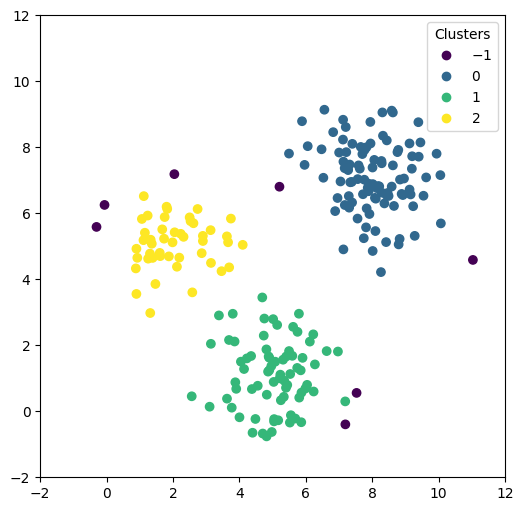

In [14]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

# Vẽ các điểm dữ liệu với màu sắc tương ứng theo cluster
scatter = plt.scatter(dat[:,0], dat[:,1], c=cluster, cmap='viridis')
plt.legend(*scatter.legend_elements(), title="Clusters")

plt.show()

### 2.3. Tính hiệu suất phân cụm

**=== Thử tính với hàm built-in của Sklearn ===**

In [19]:
from sklearn.metrics import silhouette_score

In [25]:
from sklearn.metrics import silhouette_score
silhouette_score(dat, cluster)

np.float64(0.639460128792222)

**=== Tính lại với các cụm không chứa điểm noise ===**

In [ ]:
import pandas as pd

In [16]:
# Bỏ đi các samples bị xác định là noise
mask = cluster != -1
cluster2 = cluster[mask]
dat2 = dat[mask]

print(cluster2.shape)
print(dat2.shape)

(218,)
(218, 2)


In [26]:
import pandas as pd

# Tạo một list rỗng để chứa hệ số Silhouette của mỗi sample
s_list = []

for i, sample in enumerate(dat2):
    label = cluster2[i]

    # Lấy ra các samples khác và nhãn khác
    other_samples = np.delete(dat2, i, axis=0)
    other_labels = np.delete(cluster2, i, axis=0)

    # Tính khoảng cách từ sample đến tất cả các other_samples
    distances = np.linalg.norm(other_samples - sample, axis=1)

    # Tạo dataframe với 2 cột 'distance' và 'cluster' để dùng groupby tính mean()
    df_temp = pd.DataFrame({'distance': distances, 'cluster': other_labels})
    mean_distances = df_temp.groupby('cluster')['distance'].mean()

    # Lấy ra giá trị p, q tương ứng
    p = mean_distances.get(label, 0)
    q = mean_distances.drop(label, errors='ignore').min()

    # Tính ra hệ số Silhouette cho sample
    s = (q - p) / max(p, q)
    s_list.append(s)

In [22]:
# Tính trung bình hệ số Silhouette của tất cả các samples
np.mean(s_list)

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


np.float64(nan)

**==> Thử thực hiện lại mà không bỏ giá trị noise?**